# Title: Disease Prediction using Machine Learning

# Description:

Welcome to our cutting-edge Personalized Medical Recommendation System, a powerful platform designed to assist users in understanding and managing their health. Leveraging the capabilities of machine learning, our system analyzes user-input symptoms to predict potential diseases accurately.

# Load dataset and tools

In [50]:
import  pandas as pd

In [51]:
df = pd.read_csv("datasets/Training.csv")

In [52]:
df.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


# Preprocessing

In [53]:
df.columns = df.columns.str.strip()

In [54]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("__", "_")

In [55]:
X = df.drop("prognosis", axis=1)
y = df["prognosis"]

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded = y

In [57]:
print(df.isnull().sum().sum())

0


In [58]:
X = X.astype(int)

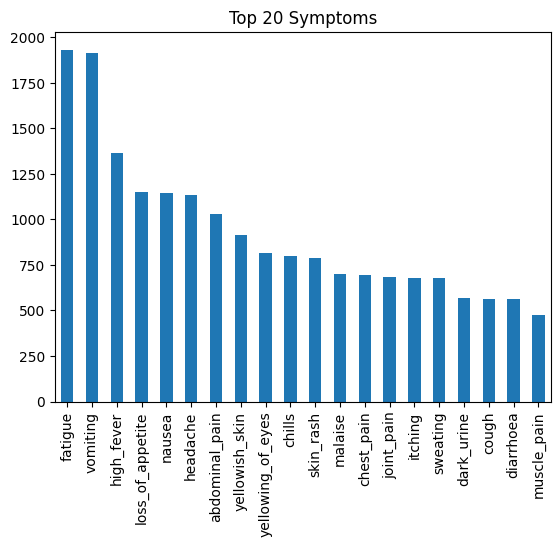

In [59]:
import matplotlib.pyplot as plt
symptom_counts = df.drop('prognosis', axis=1).sum()

symptom_counts.sort_values(ascending=False).head(20).plot(kind='bar')
plt.title("Top 20 Symptoms")
plt.show()

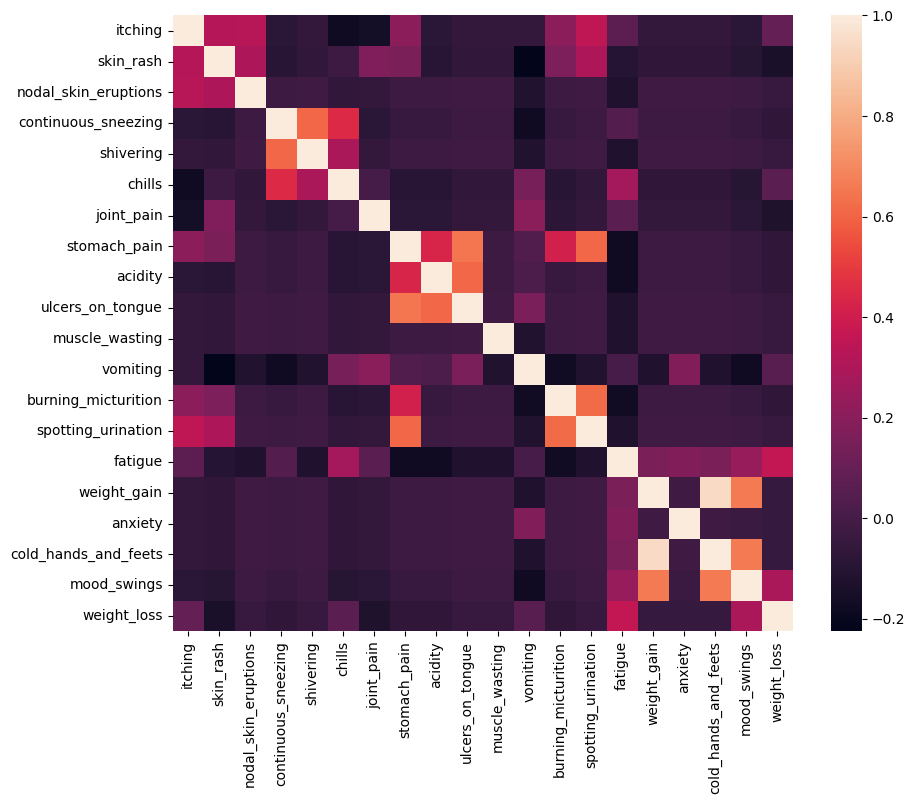

In [60]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.iloc[:, :20].corr())  # only first 20 columns
plt.show()

# Train and Test Split

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training

In [62]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [63]:
models = {
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB()
}

In [64]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

SVM Accuracy: 1.0000
Random Forest Accuracy: 1.0000
Naive Bayes Accuracy: 1.0000


In [65]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: SVM


In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


SVM Accuracy: 1.0000
Normalized Confusion Matrix:
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


<Figure size 640x480 with 0 Axes>

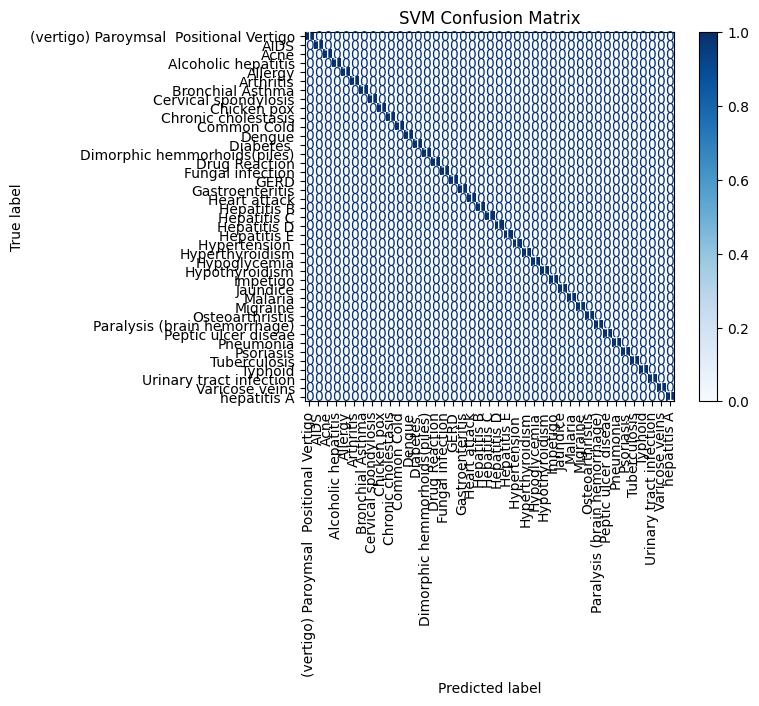


Random Forest Accuracy: 1.0000
Normalized Confusion Matrix:
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


<Figure size 640x480 with 0 Axes>

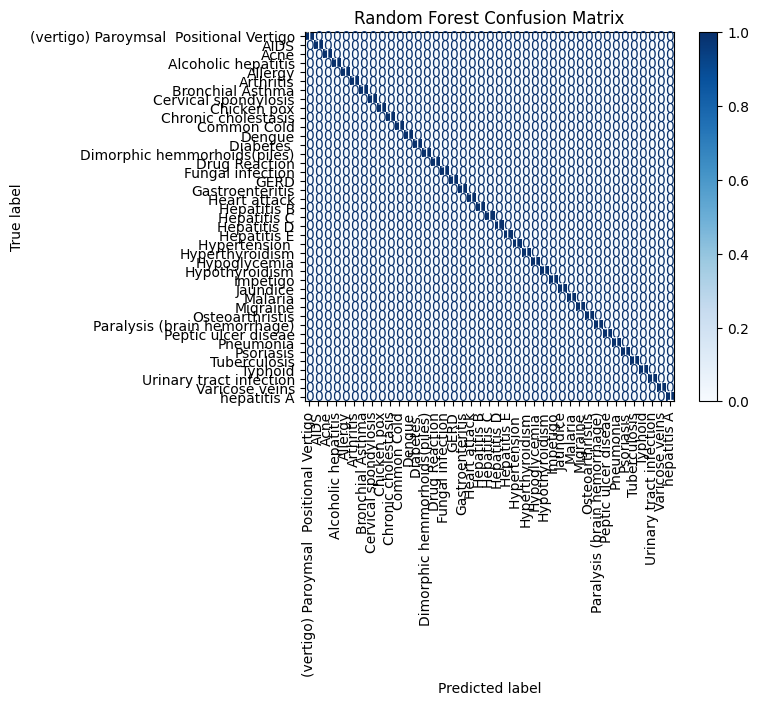


Naive Bayes Accuracy: 1.0000
Normalized Confusion Matrix:
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


<Figure size 640x480 with 0 Axes>

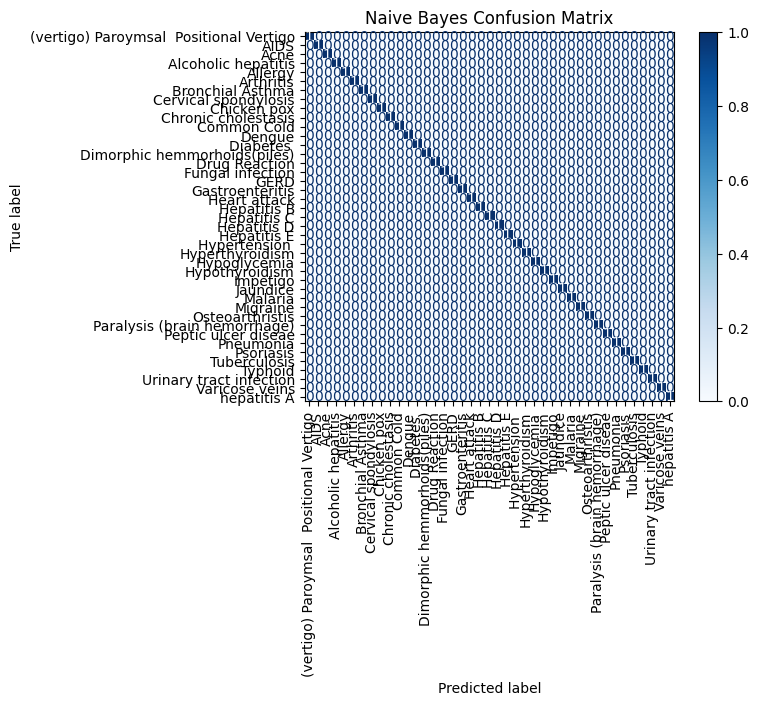

In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")

    # Confusion Matrix (normalized)
    cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

    print("Normalized Confusion Matrix:")
    print(cm_normalized)

    # Plot properly
    plt.figure()   # prevents overlap

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=le.classes_   # only if LabelEncoder used
    )

    disp.plot(cmap='Blues', xticks_rotation=90)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [68]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Model Selected:", best_model_name)


Best Model Selected: SVM


# Testing

In [78]:
sym_des = pd.read_csv("datasets/symtoms_df.csv")
precautions = pd.read_csv("datasets/precautions_df.csv")
workout = pd.read_csv("datasets/workout_df.csv")
description = pd.read_csv("datasets/description.csv")
medications = pd.read_csv('datasets/medications.csv')
diets = pd.read_csv("datasets/diets.csv")

In [79]:
feature_columns = X.columns

In [80]:
def helper(dis):
    dis = dis.strip().lower()

    desc = description[
        description['Disease'].str.strip().str.lower() == dis
    ]['Description']

    desc = " ".join(desc.values) if not desc.empty else "No description found"

    pre = precautions[
        precautions['Disease'].str.strip().str.lower() == dis
    ][['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']].values.tolist()

    med = medications[
        medications['Disease'].str.strip().str.lower() == dis
    ]['Medication'].values.tolist()

    die = diets[
        diets['Disease'].str.strip().str.lower() == dis
    ]['Diet'].values.tolist()

    wrkout = workout[
        workout['disease'].str.strip().str.lower() == dis
    ]['workout'].values.tolist()

    return desc, pre, med, die, wrkout

symptoms_dict = {'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4, 'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10, 'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15, 'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20, 'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25, 'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31, 'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36, 'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42, 'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46, 'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and_distorted_vision': 49, 'phlegm': 50, 'throat_irritation': 51, 'redness_of_eyes': 52, 'sinus_pressure': 53, 'runny_nose': 54, 'congestion': 55, 'chest_pain': 56, 'weakness_in_limbs': 57, 'fast_heart_rate': 58, 'pain_during_bowel_movements': 59, 'pain_in_anal_region': 60, 'bloody_stool': 61, 'irritation_in_anus': 62, 'neck_pain': 63, 'dizziness': 64, 'cramps': 65, 'bruising': 66, 'obesity': 67, 'swollen_legs': 68, 'swollen_blood_vessels': 69, 'puffy_face_and_eyes': 70, 'enlarged_thyroid': 71, 'brittle_nails': 72, 'swollen_extremeties': 73, 'excessive_hunger': 74, 'extra_marital_contacts': 75, 'drying_and_tingling_lips': 76, 'slurred_speech': 77, 'knee_pain': 78, 'hip_joint_pain': 79, 'muscle_weakness': 80, 'stiff_neck': 81, 'swelling_joints': 82, 'movement_stiffness': 83, 'spinning_movements': 84, 'loss_of_balance': 85, 'unsteadiness': 86, 'weakness_of_one_body_side': 87, 'loss_of_smell': 88, 'bladder_discomfort': 89, 'foul_smell_of urine': 90, 'continuous_feel_of_urine': 91, 'passage_of_gases': 92, 'internal_itching': 93, 'toxic_look_(typhos)': 94, 'depression': 95, 'irritability': 96, 'muscle_pain': 97, 'altered_sensorium': 98, 'red_spots_over_body': 99, 'belly_pain': 100, 'abnormal_menstruation': 101, 'dischromic _patches': 102, 'watering_from_eyes': 103, 'increased_appetite': 104, 'polyuria': 105, 'family_history': 106, 'mucoid_sputum': 107, 'rusty_sputum': 108, 'lack_of_concentration': 109, 'visual_disturbances': 110, 'receiving_blood_transfusion': 111, 'receiving_unsterile_injections': 112, 'coma': 113, 'stomach_bleeding': 114, 'distention_of_abdomen': 115, 'history_of_alcohol_consumption': 116, 'fluid_overload.1': 117, 'blood_in_sputum': 118, 'prominent_veins_on_calf': 119, 'palpitations': 120, 'painful_walking': 121, 'pus_filled_pimples': 122, 'blackheads': 123, 'scurring': 124, 'skin_peeling': 125, 'silver_like_dusting': 126, 'small_dents_in_nails': 127, 'inflammatory_nails': 128, 'blister': 129, 'red_sore_around_nose': 130, 'yellow_crust_ooze': 131}
diseases_list = {15: 'Fungal infection', 4: 'Allergy', 16: 'GERD', 9: 'Chronic cholestasis', 14: 'Drug Reaction', 33: 'Peptic ulcer diseae', 1: 'AIDS', 12: 'Diabetes ', 17: 'Gastroenteritis', 6: 'Bronchial Asthma', 23: 'Hypertension ', 30: 'Migraine', 7: 'Cervical spondylosis', 32: 'Paralysis (brain hemorrhage)', 28: 'Jaundice', 29: 'Malaria', 8: 'Chicken pox', 11: 'Dengue', 37: 'Typhoid', 40: 'hepatitis A', 19: 'Hepatitis B', 20: 'Hepatitis C', 21: 'Hepatitis D', 22: 'Hepatitis E', 3: 'Alcoholic hepatitis', 36: 'Tuberculosis', 10: 'Common Cold', 34: 'Pneumonia', 13: 'Dimorphic hemmorhoids(piles)', 18: 'Heart attack', 39: 'Varicose veins', 26: 'Hypothyroidism', 24: 'Hyperthyroidism', 25: 'Hypoglycemia', 31: 'Osteoarthristis', 5: 'Arthritis', 0: '(vertigo) Paroymsal  Positional Vertigo', 2: 'Acne', 38: 'Urinary tract infection', 35: 'Psoriasis', 27: 'Impetigo'}

def get_predicted_value(patient_symptoms):
    
    # Create empty dataframe with SAME columns as training
    input_df = pd.DataFrame(0, index=[0], columns=feature_columns)

    # Fill symptoms
    for symptom in patient_symptoms:
        symptom = symptom.strip().lower()
        
        if symptom in input_df.columns:
            input_df.at[0, symptom] = 1
        else:
            print(f"⚠️ Invalid symptom: {symptom}")

    # Predict
    return best_model.predict(input_df)[0]

In [81]:
# Test input
symptoms = "cough,high_fever,sweating,breathlessness"

# Preprocess
user_symptoms = [s.strip().lower() for s in symptoms.split(',')]

# Prediction
predicted_disease = get_predicted_value(user_symptoms)

print("\nRAW MODEL OUTPUT:", predicted_disease)

# Get details
desc, pre, med, die, wrkout = helper(predicted_disease)

print("\n================= PREDICTED DISEASE ============")
print(predicted_disease)

print("\n================= DESCRIPTION ==================")
print(desc)

print("\n================= PRECAUTIONS ==================")
for i, p in enumerate(pre[0] if pre else [], 1):
    print(f"{i}. {p}")

print("\n================= MEDICATIONS ==================")
for i, m in enumerate(med, 1):
    print(f"{i}. {m}")

print("\n================= WORKOUT ==================")
for i, w in enumerate(wrkout, 1):
    print(f"{i}. {w}")

print("\n================= DIET ==================")
for i, d in enumerate(die, 1):
    print(f"{i}. {d}")


RAW MODEL OUTPUT: Bronchial Asthma

================= PREDICTED DISEASE ============
Bronchial Asthma

================= DESCRIPTION ==================
Bronchial Asthma is a respiratory condition characterized by inflammation of the airways.

================= PRECAUTIONS ==================
1. switch to loose cloothing
2. take deep breaths
3. get away from trigger
4. seek help

================= MEDICATIONS ==================
1. ['Bronchodilators', 'Inhaled corticosteroids', 'Leukotriene modifiers', 'Mast cell stabilizers', 'Anticholinergics']

================= WORKOUT ==================
1. Include anti-inflammatory foods
2. Consume omega-3 fatty acids
3. Limit sodium intake
4. Stay hydrated
5. Include antioxidant-rich foods
6. Avoid sulfite-containing foods
7. Limit processed foods
8. Consume magnesium-rich foods
9. Consult a healthcare professional
10. Avoid trigger foods

================= DIET ==================
1. ['Anti-Inflammatory Diet', 'Omega-3-rich foods', 'Fruits and vege

In [83]:
import pickle

# Save model
with open('models/disease_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature columns
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Model saved successfully")

Model saved successfully
